In [ ]:
import xarray as xr
import numpy as np 
import matplotlib.pyplot as plt

In [ ]:
#read shapefile 
import geopandas as gpd
amazonia_shp_path = "../../data/amazonia_shape/Amazonia_Legal_Municipios_2024.shp"
amazonia_shp = gpd.read_file(amazonia_shp_path)
min_lon, min_lat, max_lon, max_lat = amazonia_shp.total_bounds

In [ ]:
print(min_lon, min_lat, max_lon, max_lat )

-73.9868097 -18.0415982 -43.3681715 5.2696195


In [ ]:
ds = xr.open_mfdataset("../../data/era5/*.nc", concat_dim="valid_time",combine='nested') 

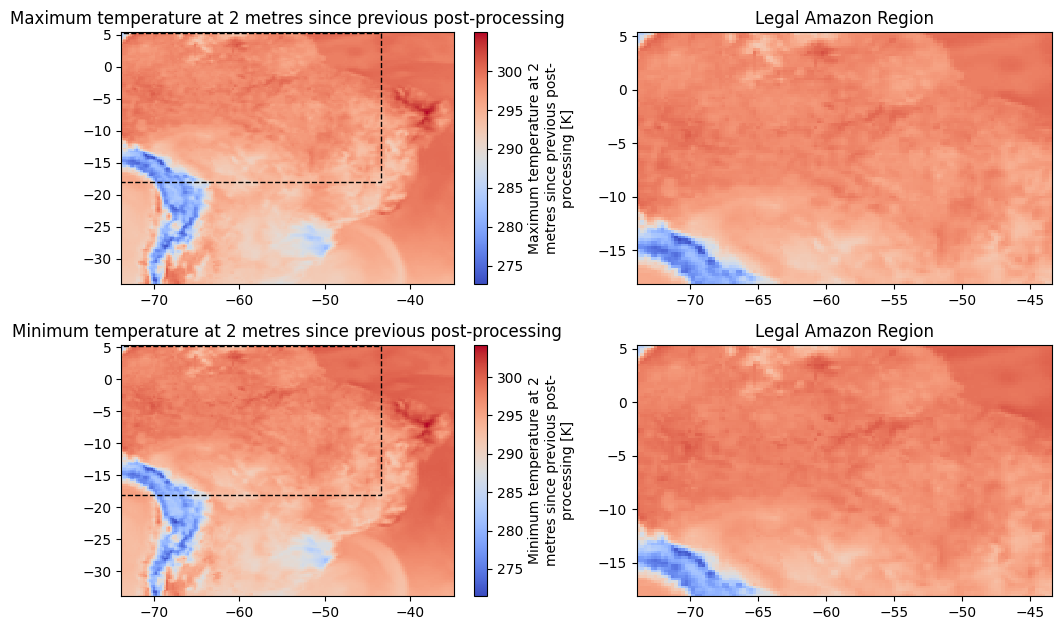

In [ ]:
areas = {'Legal Amazon': {'latitude':  [min_lat, max_lat], 'longitude': [min_lon, max_lon]},}
variables = [i for i in list(ds.variables.keys()) if i not in ['number', 'time', 'latitude','longitude','expver', 'valid_time']]

fig, axs = plt.subplots(len(variables), 2, figsize=(10, 3.2*len(variables)))

for j, var in enumerate(variables):
        vmin = ds[var].isel(valid_time=0).min().values.item()
        vmax = ds[var].isel(valid_time=0).max().values.item()

        ds[var].isel(valid_time=0).plot(ax=axs[j,0], cmap='coolwarm', add_colorbar=True, vmin=vmin, vmax=vmax)
        axs[j,0].set_title(ds[var].long_name)
        axs[j,0].set_xlabel('')
        axs[j,0].set_ylabel('')

        for i, (area, coords) in enumerate(areas.items()):

                lat_min, lat_max = coords["latitude"]
                lon_min, lon_max = coords["longitude"]

                lat_slice = slice(lat_max, lat_min) if ds.latitude.values[0] > ds.latitude.values[-1] else slice(lat_min, lat_max)
                cropped = ds[var].sel(latitude=lat_slice, longitude=slice(lon_min, lon_max))
                cropped.isel(valid_time=0).plot(ax=axs[j,i+1], cmap='coolwarm', add_colorbar=False, vmin=vmin, vmax=vmax)
                axs[j,i+1].set_title(f"{area} Region")
                axs[j,i+1].set_xlabel('')
                axs[j,i+1].set_ylabel('')

                axs[j,0].plot([lon_min, lon_max, lon_max, lon_min, lon_min],
                        [lat_min, lat_min, lat_max, lat_max, lat_min],
                        color='black', linewidth=1, linestyle='--')
                
plt.tight_layout()
plt.show()

In [ ]:
# Compute norm_means / norm_stds for the YAML config.
# Pipeline must match Era5Dataset exactly:
#   1) crop to Legal Amazon bbox (handling ERA5 descending latitude),
#   2) hourly -> daily: mn2t = daily min, mx2t = daily max,
#   3) reduce mean / std over (time, lat, lon), ignoring NaNs.

lat_descending = ds.latitude.values[0] > ds.latitude.values[-1]
lat_slice = slice(max_lat, min_lat) if lat_descending else slice(min_lat, max_lat)
ds_crop = ds.sel(latitude=lat_slice, longitude=slice(min_lon, max_lon))

daily = {
    'mn2t': ds_crop['mn2t'].resample(valid_time='1D').min(),
    'mx2t': ds_crop['mx2t'].resample(valid_time='1D').max(),
}

stats = {}
for var, da in daily.items():
    stats[var] = {
        'mean': float(da.mean(skipna=True).values),
        'std':  float(da.std(skipna=True).values),
        'units': ds[var].attrs.get('units', '?'),
    }

# Order must match surf_vars in the YAML. Era5Dataset uses ('mn2t', 'mx2t')
# which maps to ('Tmin', 'Tmax').
order = ('mn2t', 'mx2t')
print(f"units: {[stats[v]['units'] for v in order]}  # ERA5 raw, no K->C conversion")
print(f"norm_means: [{stats[order[0]]['mean']:.4f}, {stats[order[1]]['mean']:.4f}]  # {list(order)}")
print(f"norm_stds:  [{stats[order[0]]['std']:.4f}, {stats[order[1]]['std']:.4f}]    # {list(order)}")

units: ['K', 'K']  # ERA5 raw, no K->C conversion
norm_means: [294.5310, 302.0298]  # ['mn2t', 'mx2t']
norm_stds:  [4.3696, 4.1115]    # ['mn2t', 'mx2t']


In [ ]:
max_lat

np.float64(5.2696195)